# Example: California Housing End-to-End Pipeline

Demonstrates scaling, degree-2 polynomial expansion, and Ridge regression on California Housing with a visual prediction alignment plot.

Pipeline R2 Score on 2,000 California Tracts: 0.6527


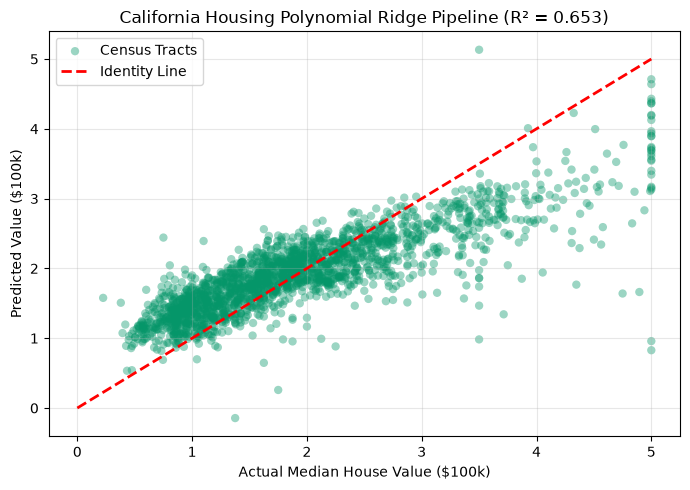

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.pipeline import PipelineScratch, StandardScalerScratch
from src.features import PolynomialFeaturesScratch
from src.linear_regression import GradientDescentLinearRegression, compute_r2

df = pd.read_csv(root_dir / "data" / "california_housing" / "california_housing.csv")
features = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]
X = df[features].values[:2000]
y = df["MedHouseVal"].values[:2000]

pipe = PipelineScratch([
    ("scaler", StandardScalerScratch()),
    ("poly", PolynomialFeaturesScratch(degree=2, interaction_only=True)),
    ("ridge", GradientDescentLinearRegression(penalty="l2", alpha=0.5, lr=0.02, n_iters=300, optimizer="adam"))
])

pipe.fit(X, y)
r2_val = pipe.score(X, y)
print(f"Pipeline R2 Score on 2,000 California Tracts: {r2_val:.4f}")

y_pred = pipe.predict(X)
plt.figure(figsize=(7, 5))
plt.scatter(y, y_pred, alpha=0.4, color='#059669', edgecolors='none', label='Census Tracts')
plt.plot([0, 5], [0, 5], 'r--', lw=2, label='Identity Line')
plt.xlabel("Actual Median House Value ($100k)")
plt.ylabel("Predicted Value ($100k)")
plt.title(f"California Housing Polynomial Ridge Pipeline (R² = {r2_val:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What You Learned
- Chaining feature scaling, polynomial interaction terms, and regularized GD in a single unified pipeline.
- Evaluating non-linear feature expansion performance on spatial housing data.